# **MScFE 690: CapstoneProject**
## Student Group: **11186**
### Members:
1. **Vahid Nikoofard**
2. **Dipanshu Sharma**
3. **Rhesa Prabowo Budhidarmo**


**Influence Diagram as A Decision-Making Tool for Factor Investing**

In [14]:
# installing the libraries which are not available
!pip install statsmodels pgmpy pomegranate pymc3 vectorbt tigramite dynetears lingam fredapi


ERROR: Ignored the following versions that require a different python version: 0.15.0 Requires-Python >=3.6, <3.9; 0.15.1 Requires-Python >=3.6, <3.9; 0.15.2 Requires-Python >=3.6, <3.9; 0.15.3 Requires-Python >=3.6, <3.9; 0.15.4 Requires-Python >=3.6, <3.9; 0.15.5 Requires-Python >=3.6, <3.9; 0.15.6 Requires-Python >=3.6, <3.9; 0.15.7 Requires-Python >=3.6, <3.9; 0.16.0 Requires-Python >=3.6, <3.9; 0.16.1 Requires-Python >=3.6, <3.9; 0.16.2 Requires-Python >=3.6, <3.9; 0.16.3 Requires-Python >=3.6, <3.9; 0.16.4 Requires-Python >=3.6, <3.9; 0.16.5 Requires-Python >=3.6, <3.9; 0.16.6 Requires-Python >=3.6, <3.9; 0.17.0 Requires-Python >=3.6, <3.9; 0.17.1 Requires-Python >=3.6, <3.9; 0.17.2 Requires-Python >=3.6, <3.9; 0.17.3 Requires-Python >=3.6, <3.9; 0.17.4 Requires-Python >=3.6, <3.9; 0.17.5 Requires-Python >=3.6, <3.9; 0.17.6 Requires-Python >=3.6, <3.10; 0.17.7 Requires-Python >=3.6, <3.10; 0.18.0 Requires-Python >=3.6, <3.10; 0.18.1 Requires-Python >=3.6, <3.10; 0.18.2 Requires-P

In [18]:
!python --version

Python 3.12.11


In [13]:
import dynetears

ModuleNotFoundError: No module named 'dynetears'

In [ ]:
# importing the required libraries

import pandas as pd
import numpy as np
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import yfinance as yf
from fredapi import Fred

from sklearn.preprocessing import StandardScaler
import lingam
import networkx as nx

# **Downloading and Preparing the Required Datasets**

In [ ]:
# global parameters

fred_api_key_dipanshu = 'ae213ec36f24001ac4966f114b7424d2'
fred = Fred(api_key=fred_api_key_dipanshu)

The following ETFs represent large, diversified baskets of EM stocks across Emerging Market regions like Asia, Latin America, Eastern Europe, and Africa. They serve as accessible proxies for the overall equity performance within Emerging Markets.

- **EEM:** iShares MSCI Emerging Markets ETF
- **VWO:** Vanguard FTSE Emerging Markets ETF
- **IEMG:** iShares Core MSCI Emerging Markets ETF

In [ ]:
em_etf_tickers = ['EEM', 'VWO', 'IEMG']

# downloading the data from yfinance, IEMG data starts from 2012-10-24, whicle other two have historical data as well previous to 2012
em_etf_price_data = yf.download(em_etf_tickers, start='2012-10-24', end='2025-01-01', progress = False)['Close']
em_etf_price_data.head(5)

Ticker,EEM,IEMG,VWO
Date,,,
2012-10-24,31.014999,34.951763,28.784266
2012-10-25,31.354750,35.183701,29.069122
2012-10-26,31.113165,34.930008,28.867638
2012-10-31,31.067860,34.959000,28.825951
2012-11-01,31.573704,35.517136,29.249762


In [ ]:
# handling missing values by forward and backward filling
em_etf_price_data.fillna(method='ffill', inplace=True)
em_etf_price_data.fillna(method='bfill', inplace=True)

# Calculate monthly returns, as that is very common for factor investing
em_etf_monthly_prices = em_etf_price_data.resample('M').last()
em_etf_monthly_returns = em_etf_monthly_prices.pct_change().dropna()
em_etf_monthly_returns.head(5)

Ticker,EEM,IEMG,VWO
Date,,,
2012-11-30,0.015553,0.015965,0.012774
2012-12-31,0.068036,0.067827,0.070671
2013-01-31,-0.002932,-0.002299,0.000674
2013-02-28,-0.022840,-0.015361,-0.023564
2013-03-31,-0.010183,-0.010141,-0.012665


In [ ]:
# Example macro series for EM-related indicators -- #TODO: need to be reviewed with group and need to include few more
macro_series = {
    'US_GDP': 'GDP',
    'US_CPI': 'CPIAUCSL',
    'US_10Y_Treasury': 'DGS10',
    'China_GDP': 'NGDPRXDCCNA',
    'India_GDP': 'NGDPRNSAXDCINQ'
}

# downloading the macroeconomic data from FRED
macro_data = pd.DataFrame()
for name, series_id in macro_series.items():
  data = fred.get_series(series_id, observation_start='2012-10-01')
  macro_data[name] = data

macro_data.index = pd.to_datetime(macro_data.index)
macro_data = macro_data.resample('M').last().ffill().bfill()
macro_data.head(5)

,US_GDP,US_CPI,US_10Y_Treasury,China_GDP,India_GDP
2012-10-31,16420.419,231.638,1.64,68060239.8,23447672.1
2012-11-30,16420.419,231.638,1.64,68060239.8,23447672.1
2012-12-31,16420.419,231.638,1.64,68060239.8,23447672.1
2013-01-31,16648.189,231.679,1.64,68060239.8,24670818.7
2013-02-28,16648.189,231.679,1.64,68060239.8,24670818.7


In [ ]:
# after indexing em_etf_monthly_returns and macro_data to monthly, we need to combine two datasets
em_etf_macro_combined_data = pd.concat([em_etf_monthly_returns, macro_data], axis=1)
em_etf_macro_combined_data = em_etf_macro_combined_data.dropna()
em_etf_macro_combined_data.head(5)

,EEM,IEMG,VWO,US_GDP,US_CPI,US_10Y_Treasury,China_GDP,India_GDP
2012-11-30,0.015553,0.015965,0.012774,16420.419,231.638,1.64,68060239.8,23447672.1
2012-12-31,0.068036,0.067827,0.070671,16420.419,231.638,1.64,68060239.8,23447672.1
2013-01-31,-0.002932,-0.002299,0.000674,16648.189,231.679,1.64,68060239.8,24670818.7
2013-02-28,-0.022840,-0.015361,-0.023564,16648.189,231.679,1.64,68060239.8,24670818.7
2013-03-31,-0.010183,-0.010141,-0.012665,16648.189,231.679,1.64,68060239.8,24670818.7


## **EDA (Exploratory Data Analysis)**

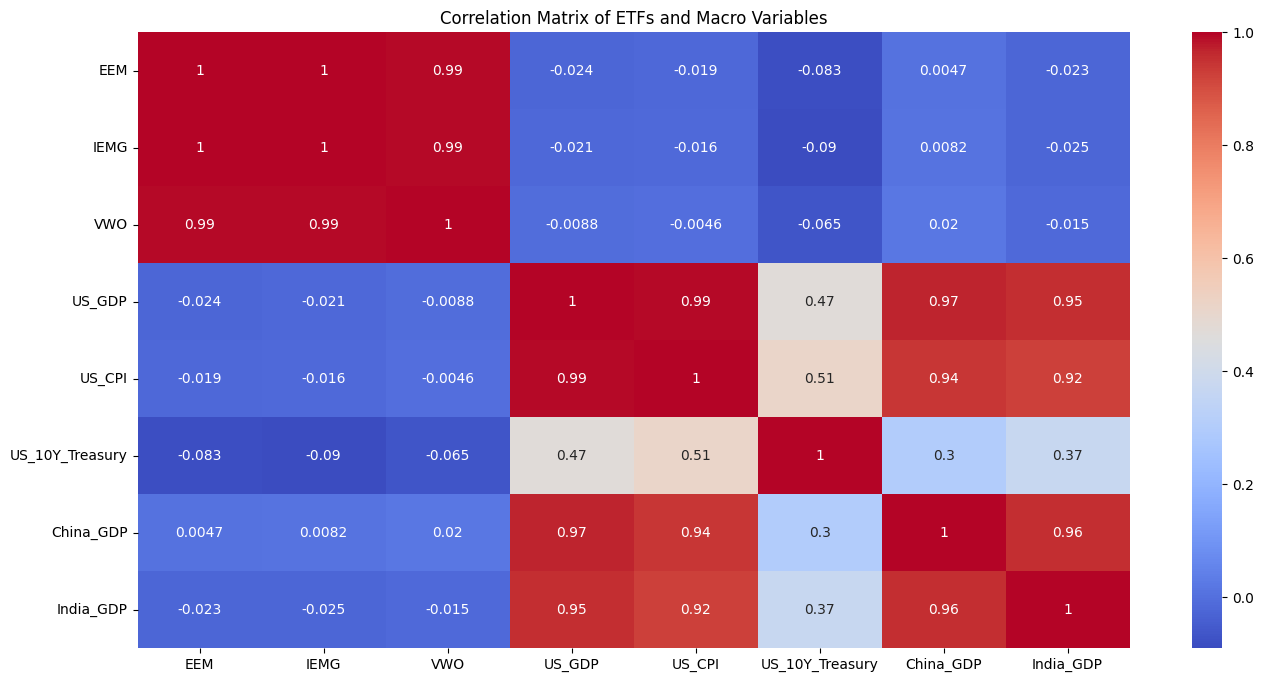

In [ ]:
# Correlation heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(em_etf_macro_combined_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of ETFs and Macro Variables')
plt.show()

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

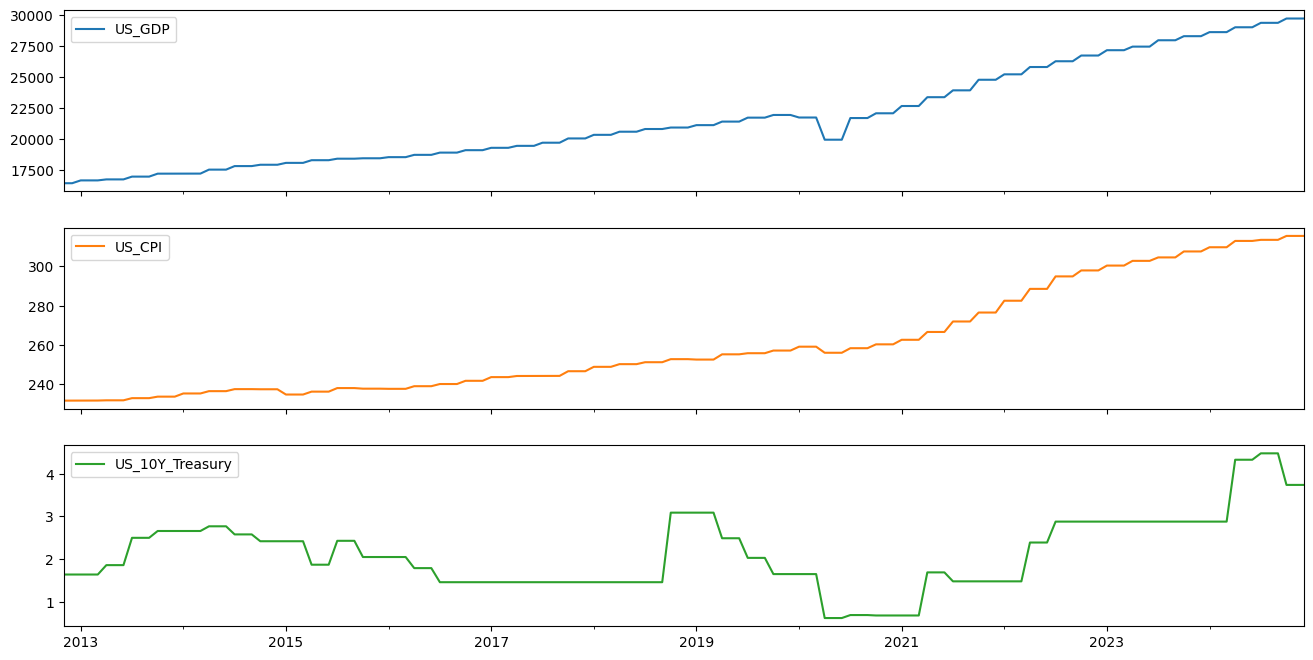

In [ ]:
# time series plot of selected series with index as timeperiod
em_etf_macro_combined_data[['US_GDP', 'US_CPI', 'US_10Y_Treasury']].plot(figsize=(16, 8), subplots = True)


In [ ]:
scaler = StandardScaler()
em_etf_macro_normalized_data = pd.DataFrame(scaler.fit_transform(em_etf_macro_combined_data),
                                            columns=em_etf_macro_combined_data.columns,
                                            index=em_etf_macro_combined_data.index)

In [ ]:
model = lingam.DirectLiNGAM()
model.fit(em_etf_macro_normalized_data)
dag_adjacency = model.adjacency_matrix_

# showing inferred adjacency matrix (causal structure)
adjacency_matrix = pd.DataFrame(dag_adjacency, columns=em_etf_macro_combined_data.columns, index=em_etf_macro_combined_data.columns)
adjacency_matrix

,EEM,IEMG,VWO,US_GDP,US_CPI,US_10Y_Treasury,China_GDP,India_GDP
EEM,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
IEMG,0.997517,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
VWO,0.426799,0.566233,0.0,0.000000,0.000000,0.0,0.000000,0.000000
US_GDP,0.000000,0.000000,0.0,0.000000,0.754787,0.0,0.000000,0.257006
US_CPI,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
US_10Y_Treasury,0.000000,0.000000,0.0,1.957048,0.620749,0.0,-2.177674,0.000000
China_GDP,0.000000,0.000000,0.0,1.700250,-0.895415,0.0,0.000000,0.161816
India_GDP,0.000000,0.000000,0.0,0.000000,0.923895,0.0,0.000000,0.000000


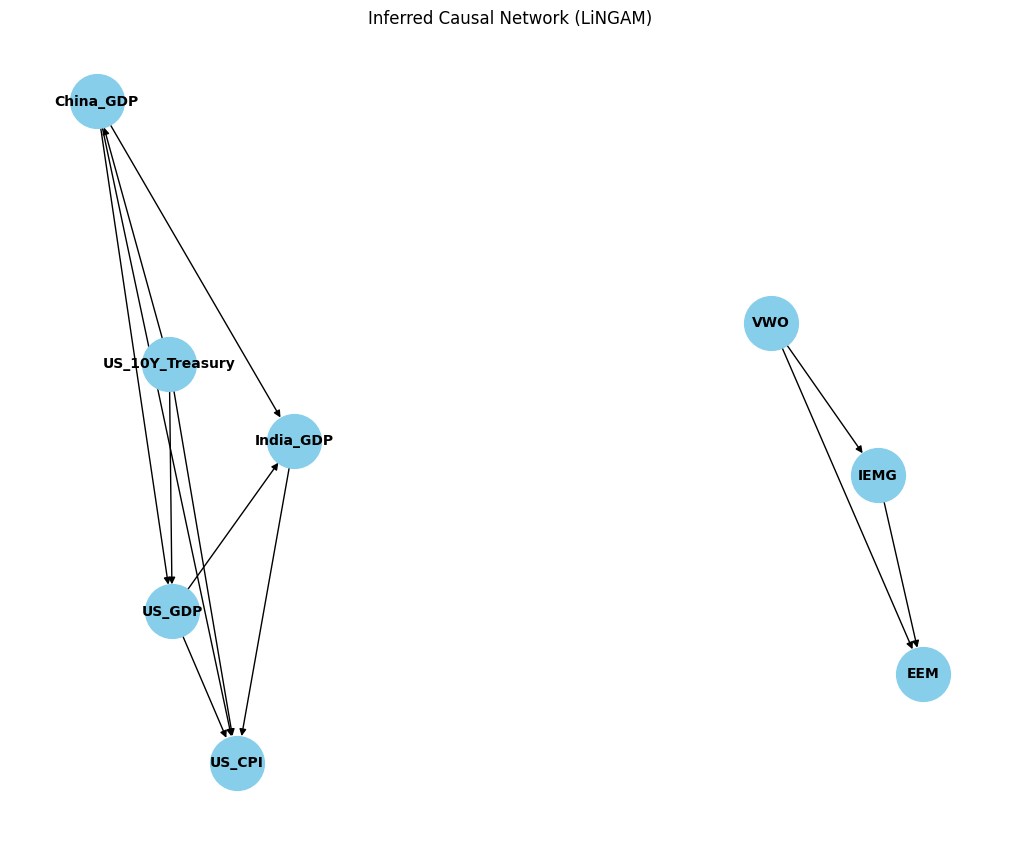

In [ ]:
G = nx.DiGraph(dag_adjacency)
G = nx.relabel_nodes(G, dict(enumerate(em_etf_macro_combined_data.columns)))

plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_size=1500, node_color='skyblue', font_size=10, font_weight='bold')
plt.title("Inferred Causal Network (LiNGAM)")
plt.show()